In [1]:
# ==========================================
# 1. INSTALL & IMPORT LIBRARY
# ==========================================
# Menambahkan 'prophet' ke dalam daftar instalasi
!pip install pmdarima statsmodels scikit-learn matplotlib seaborn pandas numpy tensorflow prophet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive

from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error, r2_score, confusion_matrix, ConfusionMatrixDisplay

# Import library untuk Deep Learning (LSTM)
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM
import tensorflow as tf

# Import library Prophet
from prophet import Prophet

import warnings
warnings.filterwarnings('ignore')

# Set seed agar hasil LSTM bisa direproduksi ulang (konsisten)
tf.random.set_seed(42)
np.random.seed(42)

In [2]:
# ==========================================
# 2. MOUNT GOOGLE DRIVE & BACA DATA
# ==========================================
print("Menghubungkan ke Google Drive...")
drive.mount('/content/drive')

file_path = '/content/drive/MyDrive/Colab Notebooks/Chocolate Sales.csv'

print(f"\nMembaca data dari: {file_path} ...")
try:
    df = pd.read_csv(file_path)
    print("Berhasil memuat dataset!\n")
except FileNotFoundError:
    print("ERROR: File tidak ditemukan. Pastikan nama file dan path di Drive sudah benar!")
    raise

# Preprocessing Tanggal & Agregasi Mingguan
df['Date'] = pd.to_datetime(df['Date'], format='%d/%m/%Y', errors='coerce')
df_daily = df.groupby('Date')['Boxes Shipped'].sum().reset_index()
df_daily.set_index('Date', inplace=True)

y = df_daily['Boxes Shipped'].resample('W').sum()

train_size = int(len(y) * 0.8)
train, test = y.iloc[:train_size], y.iloc[train_size:]

print(f"Total Data Mingguan: {len(y)} minggu")
print(f"Data Training      : {len(train)} minggu")
print(f"Data Testing       : {len(test)} minggu\n")


Menghubungkan ke Google Drive...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

Membaca data dari: /content/drive/MyDrive/Colab Notebooks/Chocolate Sales.csv ...
Berhasil memuat dataset!

Total Data Mingguan: 139 minggu
Data Training      : 111 minggu
Data Testing       : 28 minggu



In [3]:
# ==========================================
# 3. FUNGSI METRIK EVALUASI
# ==========================================
def smape(y_true, y_pred):
    return np.mean(2.0 * np.abs(y_true - y_pred) / (np.abs(y_true) + np.abs(y_pred))) * 100

def mase(y_true, y_pred, y_train):
    naive_error = np.mean(np.abs(np.diff(y_train)))
    return mean_absolute_error(y_true, y_pred) / naive_error if naive_error != 0 else np.nan

def evaluate_model(name, y_true, y_pred, y_train, aic='N/A', bic='N/A'):
    return {
        'Model': name,
        'MAE': round(mean_absolute_error(y_true, y_pred), 2),
        'RMSE': round(np.sqrt(mean_squared_error(y_true, y_pred)), 2),
        'MAPE (%)': round(mean_absolute_percentage_error(y_true, y_pred) * 100, 2),
        'SMAPE (%)': round(smape(y_true, y_pred), 2),
        'MASE': round(mase(y_true, y_pred, y_train), 2),
        'R²': round(r2_score(y_true, y_pred), 2),
        'AIC': round(aic, 2) if isinstance(aic, (int, float)) else aic,
        'BIC': round(bic, 2) if isinstance(bic, (int, float)) else bic
    }

metrics_list = []
predictions = pd.DataFrame(index=test.index)
predictions['Aktual'] = test

In [4]:
# ==========================================
# 4. TRAINING & PREDIKSI MODEL
# ==========================================

# A. Holt-Winters (dengan tuning multiplicative seasonal)
print("Melatih model Holt-Winters...")
try:
    hw_model = ExponentialSmoothing(train, trend='add', seasonal='mul', seasonal_periods=52, initialization_method="estimated", damped_trend=True).fit()
    predictions['Holt-Winters'] = hw_model.forecast(len(test))
    metrics_list.append(evaluate_model('Holt-Winters', test, predictions['Holt-Winters'], train, hw_model.aic, hw_model.bic))
except:
    print("Holt-Winters multiplicative gagal, gunakan additive...")
    hw_model = ExponentialSmoothing(train, trend='add', seasonal='add', seasonal_periods=52, initialization_method="estimated", damped_trend=True).fit()
    predictions['Holt-Winters'] = hw_model.forecast(len(test))
    metrics_list.append(evaluate_model('Holt-Winters', test, predictions['Holt-Winters'], train, hw_model.aic, hw_model.bic))

# B. SARIMA (dengan auto-tuning yang lebih detail)
print("Melatih model SARIMA dengan auto-tuning...")
from pmdarima import auto_arima
sarima_model = auto_arima(train, seasonal=True, m=52, max_p=5, max_q=5, max_P=2, max_Q=2, trace=False, error_action='ignore', suppress_warnings=True, stepwise=True)
predictions['SARIMA'] = sarima_model.predict(n_periods=len(test))
metrics_list.append(evaluate_model('SARIMA', test, predictions['SARIMA'], train, sarima_model.aic(), sarima_model.bic()))

# C. Random Forest (dengan fitur lag + kalender)
print("Melatih model Random Forest...")

def create_lag_features(series, lag=5):
    df = series.to_frame(name='Boxes Shipped')
    for i in range(1, lag + 1):
        df[f'lag_{i}'] = df['Boxes Shipped'].shift(i)
    # Tambah rolling statistics lebih banyak
    df['rolling_mean_2'] = df['Boxes Shipped'].rolling(window=2).mean()
    df['rolling_mean_4'] = df['Boxes Shipped'].rolling(window=4).mean()
    df['rolling_mean_8'] = df['Boxes Shipped'].rolling(window=8).mean()
    df['rolling_std_4'] = df['Boxes Shipped'].rolling(window=4).std()
    df['rolling_std_8'] = df['Boxes Shipped'].rolling(window=8).std()
    # Tambah momentum features
    df['momentum_1'] = df['Boxes Shipped'].diff(1)
    df['momentum_3'] = df['Boxes Shipped'].diff(3)
    df['month'] = df.index.month
    df['week'] = df.index.isocalendar().week
    df['day_of_year'] = df.index.dayofyear
    return df.dropna()

full_series = pd.concat([train, test])
full_rf = create_lag_features(full_series, lag=5)

train_rf = full_rf.loc[train.index.intersection(full_rf.index)]
test_rf = full_rf.loc[test.index.intersection(full_rf.index)]

feature_cols = [f'lag_{i}' for i in range(1, 6)] + ['rolling_mean_2', 'rolling_mean_4', 'rolling_mean_8', 'rolling_std_4', 'rolling_std_8', 'momentum_1', 'momentum_3', 'month', 'week', 'day_of_year']
X_train_rf = train_rf[feature_cols]
y_train_rf = train_rf['Boxes Shipped']
X_test_rf = test_rf[feature_cols]

rf_model = RandomForestRegressor(n_estimators=500, max_depth=15, min_samples_split=3, min_samples_leaf=1, random_state=42, n_jobs=-1)
rf_model.fit(X_train_rf, y_train_rf)
predictions['Random Forest'] = rf_model.predict(X_test_rf)
metrics_list.append(evaluate_model('Random Forest', test_rf['Boxes Shipped'], predictions['Random Forest'], train))


# D. LSTM (Deep Learning)
print("Melatih model LSTM (Deep Learning)...")
scaler = MinMaxScaler(feature_range=(0, 1))
train_scaled = scaler.fit_transform(train.values.reshape(-1, 1))

look_back = 4
X_train_lstm, y_train_lstm = [], []
for i in range(look_back, len(train_scaled)):
    X_train_lstm.append(train_scaled[i-look_back:i, 0])
    y_train_lstm.append(train_scaled[i, 0])
X_train_lstm, y_train_lstm = np.array(X_train_lstm), np.array(y_train_lstm)
X_train_lstm = np.reshape(X_train_lstm, (X_train_lstm.shape[0], X_train_lstm.shape[1], 1))

inputs = y[len(y) - len(test) - look_back:].values.reshape(-1, 1)
inputs = scaler.transform(inputs)

X_test_lstm = []
for i in range(look_back, len(inputs)):
    X_test_lstm.append(inputs[i-look_back:i, 0])
X_test_lstm = np.array(X_test_lstm)
X_test_lstm = np.reshape(X_test_lstm, (X_test_lstm.shape[0], X_test_lstm.shape[1], 1))

from tensorflow.keras.layers import Dropout, Bidirectional

lstm_model = Sequential()
lstm_model.add(Bidirectional(LSTM(64, return_sequences=True, input_shape=(look_back, 1))))
lstm_model.add(Dropout(0.2))
lstm_model.add(Bidirectional(LSTM(32, return_sequences=True)))
lstm_model.add(Dropout(0.2))
lstm_model.add(Bidirectional(LSTM(16)))
lstm_model.add(Dropout(0.2))
lstm_model.add(Dense(8, activation='relu'))
lstm_model.add(Dense(1))
lstm_model.compile(loss='mean_squared_error', optimizer='adam', metrics=['mae'])

lstm_model.fit(X_train_lstm, y_train_lstm, epochs=150, batch_size=4, verbose=0, validation_split=0.1)
lstm_pred_scaled = lstm_model.predict(X_test_lstm, verbose=0)
lstm_pred = scaler.inverse_transform(lstm_pred_scaled)
predictions['LSTM'] = lstm_pred.flatten()
metrics_list.append(evaluate_model('LSTM', test, predictions['LSTM'], train))


# E. Prophet (Meta) dengan tuning advanced
print("Melatih model Prophet dengan tuning advanced...")
train_prophet = train.reset_index()
train_prophet.columns = ['ds', 'y']

prophet_model = Prophet(yearly_seasonality='auto', weekly_seasonality=True, daily_seasonality=False, interval_width=0.95)
prophet_model.add_seasonality(name='monthly', period=30.5, fourier_order=8)
prophet_model.add_seasonality(name='quarterly', period=91.25, fourier_order=5)
prophet_model.add_seasonality(name='semi_annual', period=182.5, fourier_order=3)

prophet_model.fit(train_prophet)

future = prophet_model.make_future_dataframe(periods=len(test), freq='W')
forecast = prophet_model.predict(future)

predictions['Prophet'] = forecast.set_index('ds').reindex(test.index)['yhat'].values
metrics_list.append(evaluate_model('Prophet', test, predictions['Prophet'], train))

# Validasi cross-validation Prophet jika tersedia
try:
    from prophet.diagnostics import cross_validation, performance_metrics
    horizon_days = max(28, len(test) * 7)
    df_cv = cross_validation(prophet_model, initial='90 days', period='30 days', horizon=f'{horizon_days} days', parallel='processes')
    df_perf = performance_metrics(df_cv)
    print(f"Prophet cross-validation SMAPE: {df_perf['smape'].median():.2f}%")
except Exception as e:
    print('Peringatan: cross-validation Prophet gagal atau tidak tersedia:', e)

Melatih model Holt-Winters...
Holt-Winters multiplicative gagal, gunakan additive...
Melatih model SARIMA dengan auto-tuning...
Melatih model Random Forest...
Melatih model LSTM (Deep Learning)...
Melatih model Prophet dengan tuning advanced...


INFO:prophet:Making 17 forecasts with cutoffs between 2022-04-13 00:00:00 and 2023-08-06 00:00:00
INFO:prophet:Applying in parallel with <concurrent.futures.process.ProcessPoolExecutor object at 0x7b171b3ee990>
INFO:prophet:Skipping MAPE because y close to 0


Prophet cross-validation SMAPE: 1.71%


In [5]:
# ==========================================
# 5. MENAMPILKAN HASIL EVALUASI
# ==========================================
df_metrics = pd.DataFrame(metrics_list)
print("\n=== HASIL EVALUASI MODEL ===")
display(df_metrics)

# Tampilkan best model berdasarkan SMAPE
best_model_idx = df_metrics['SMAPE (%)'].idxmin()
best_model = df_metrics.loc[best_model_idx, 'Model']
best_smape = df_metrics.loc[best_model_idx, 'SMAPE (%)']
print(f"\n🏆 Model Terbaik: {best_model} dengan SMAPE {best_smape}%")

# Feature Importance untuk Random Forest
print("\n=== FEATURE IMPORTANCE (RANDOM FOREST) ===")
feature_importance = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)
print(feature_importance.head(10))


=== HASIL EVALUASI MODEL ===


,Model,MAE,RMSE,MAPE (%),SMAPE (%),MASE,R²,AIC,BIC
0,Holt-Winters,803.04,1028.52,17.19,17.81,0.62,0.59,904.88,1059.32
1,SARIMA,807.46,1038.42,17.36,17.93,0.63,0.58,658.56,662.68
2,Random Forest,601.02,751.56,12.73,13.03,0.47,0.78,N/A,N/A
3,LSTM,1158.86,1568.36,30.46,23.59,0.90,0.05,N/A,N/A
4,Prophet,1163.02,1360.12,26.80,24.16,0.90,0.29,N/A,N/A



🏆 Model Terbaik: Random Forest dengan SMAPE 13.03%

=== FEATURE IMPORTANCE (RANDOM FOREST) ===
           Feature  Importance
13            week    0.547849
5   rolling_mean_2    0.151044
14     day_of_year    0.104949
12           month    0.087292
10      momentum_1    0.052607
11      momentum_3    0.015267
6   rolling_mean_4    0.010238
1            lag_2    0.009013
8    rolling_std_4    0.006431
0            lag_1    0.005860


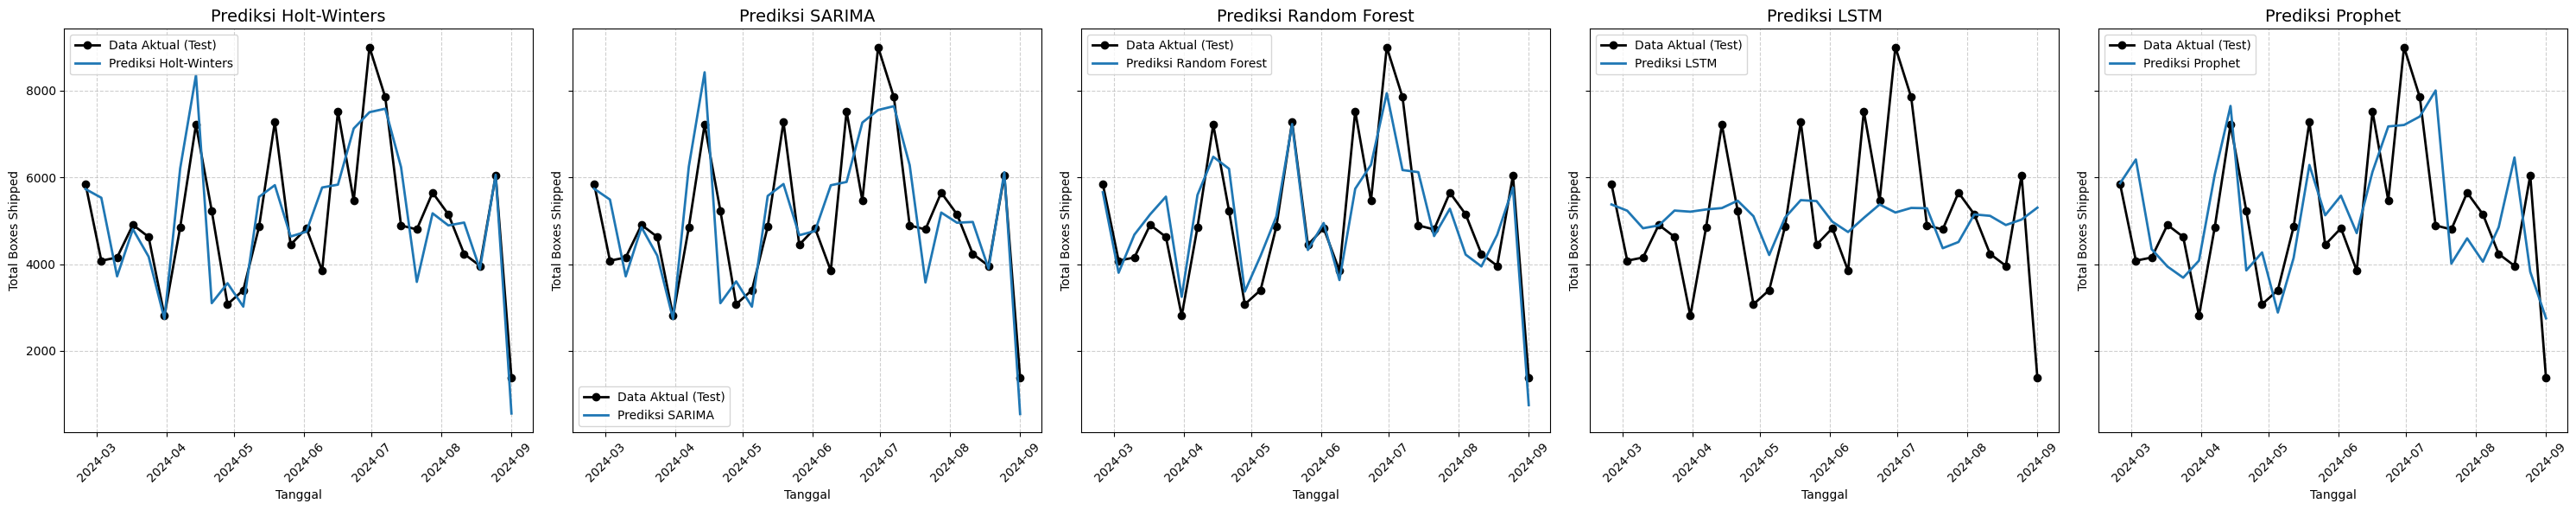

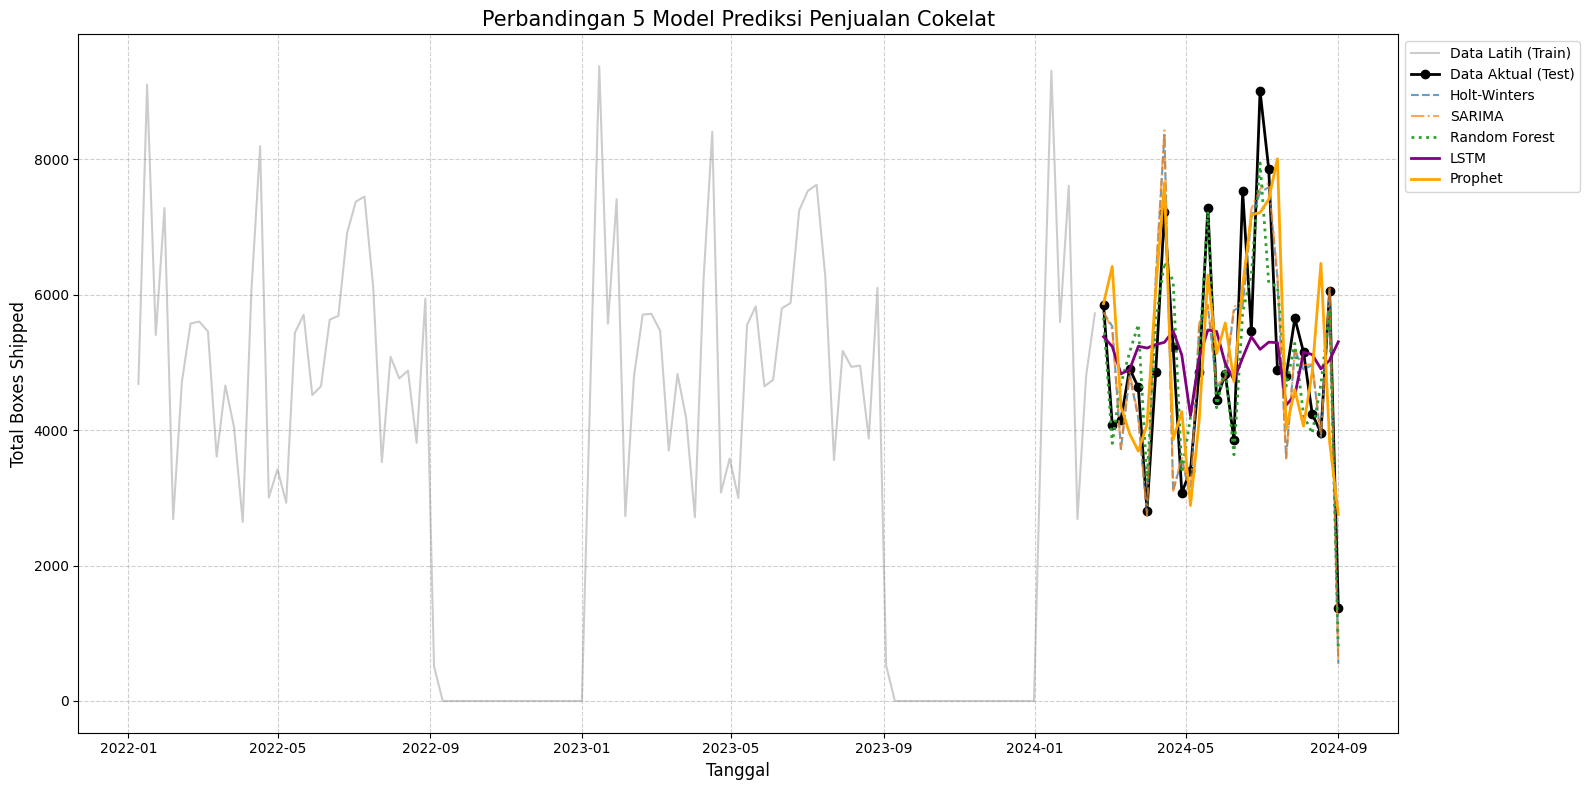


=== ANALISIS RESIDUAL (ERROR DISTRIBUTION) ===


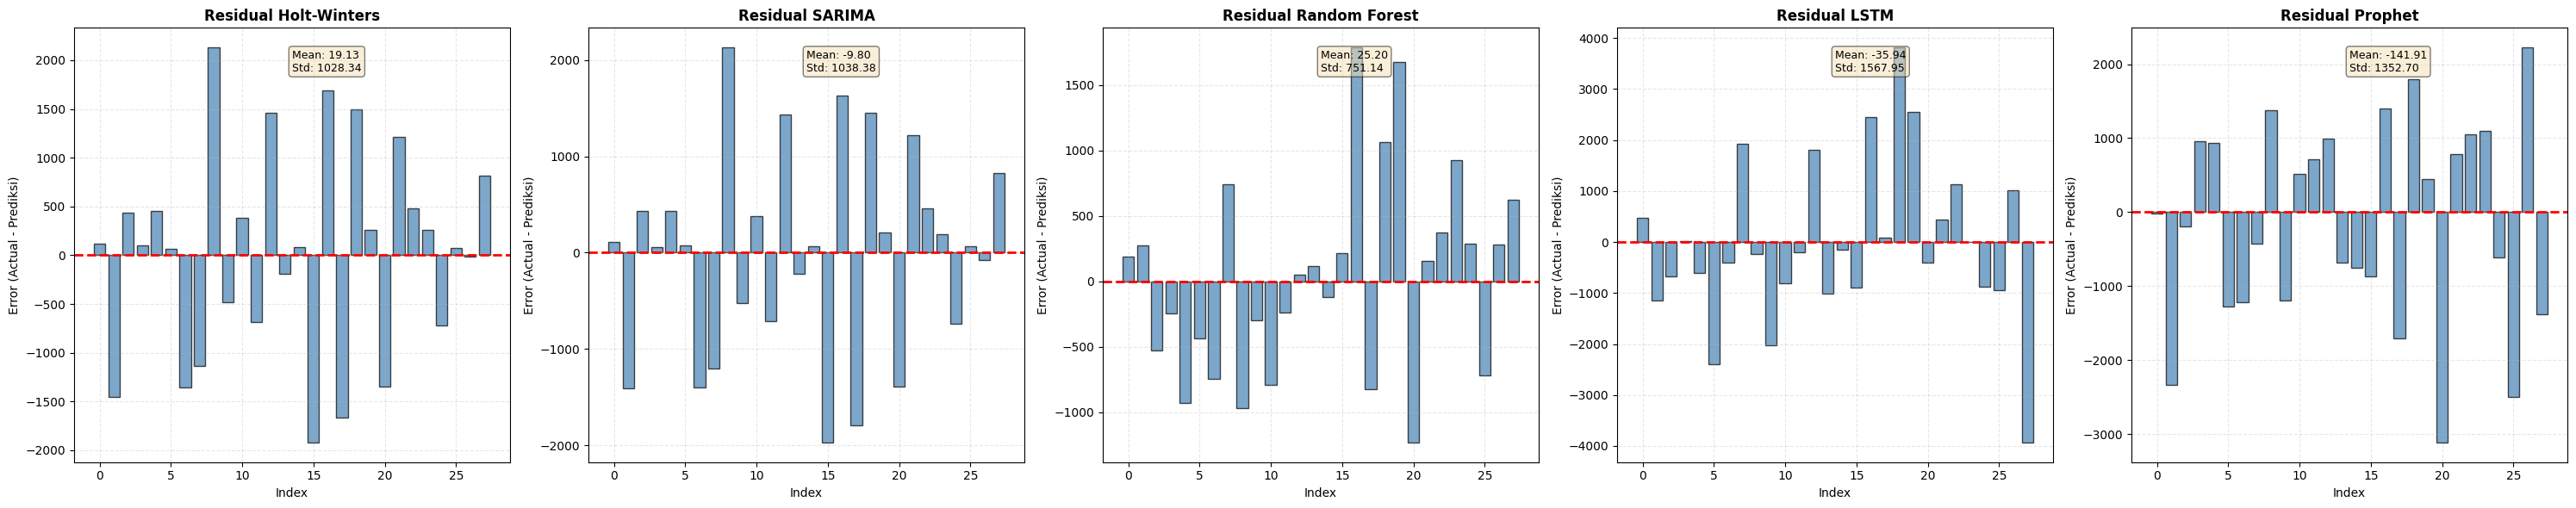


=== RANKING MODEL (SORTED BY SMAPE) ===
        Model  SMAPE (%)     MAE    RMSE   R²
Random Forest      13.03  601.02  751.56 0.78
 Holt-Winters      17.81  803.04 1028.52 0.59
       SARIMA      17.93  807.46 1038.42 0.58
         LSTM      23.59 1158.86 1568.36 0.05
      Prophet      24.16 1163.02 1360.12 0.29


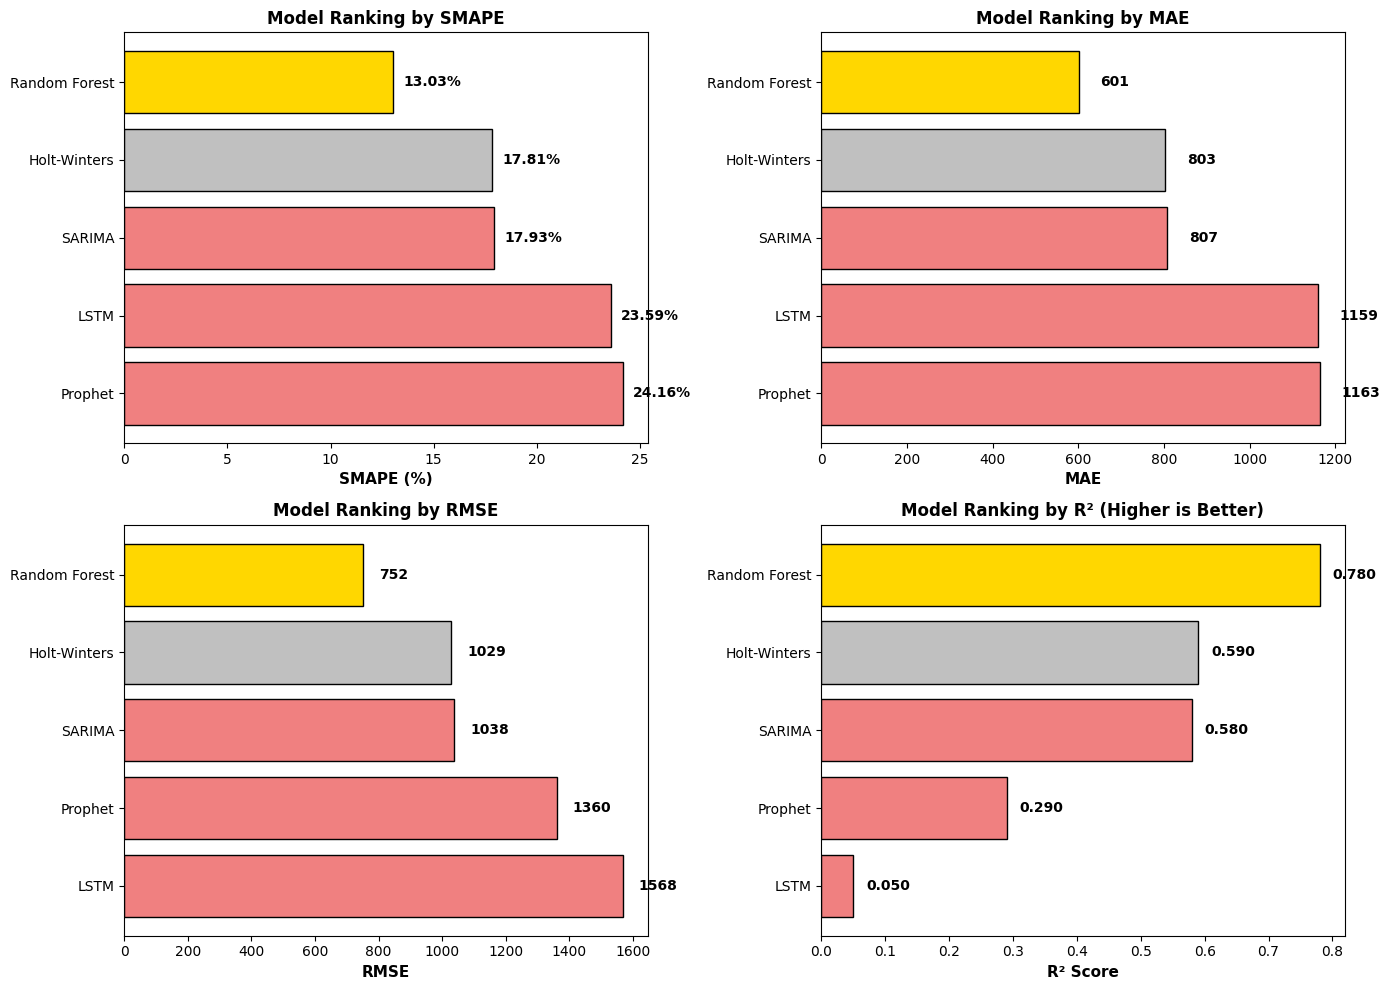

In [6]:
# ==========================================
# 6. GRAFIK PERBANDINGAN PREDIKSI (TERPISAH PER MODEL)
# ==========================================
models_to_plot = ['Holt-Winters', 'SARIMA', 'Random Forest', 'LSTM', 'Prophet']
fig, axes = plt.subplots(1, 5, figsize=(30, 6), sharey=True)

for idx, model in enumerate(models_to_plot):
    axes[idx].plot(test.index, test, label='Data Aktual (Test)', color='black', marker='o', linewidth=2)
    axes[idx].plot(test.index, predictions[model], label=f'Prediksi {model}', linestyle='-', linewidth=2)
    axes[idx].set_title(f'Prediksi {model}', fontsize=14)
    axes[idx].set_xlabel('Tanggal', fontsize=10)
    axes[idx].set_ylabel('Total Boxes Shipped', fontsize=10)
    axes[idx].legend()
    axes[idx].grid(True, linestyle='--', alpha=0.6)
    axes[idx].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

plt.figure(figsize=(16, 8))
plt.plot(train.index, train, label='Data Latih (Train)', color='grey', alpha=0.4)
plt.plot(test.index, test, label='Data Aktual (Test)', color='black', marker='o', linewidth=2)

plt.plot(test.index, predictions['Holt-Winters'], label='Holt-Winters', linestyle='--', alpha=0.7)
plt.plot(test.index, predictions['SARIMA'], label='SARIMA', linestyle='-.', alpha=0.7)
plt.plot(test.index, predictions['Random Forest'], label='Random Forest', linestyle=':', linewidth=2)
plt.plot(test.index, predictions['LSTM'], label='LSTM', color='purple', linestyle='-', linewidth=2)
# Tambahan Garis untuk Prophet
plt.plot(test.index, predictions['Prophet'], label='Prophet', color='orange', linestyle='-', linewidth=2)

plt.title('Perbandingan 5 Model Prediksi Penjualan Cokelat', fontsize=15)
plt.xlabel('Tanggal', fontsize=12)
plt.ylabel('Total Boxes Shipped', fontsize=12)
plt.legend(loc='upper left', bbox_to_anchor=(1, 1)) # Geser legend ke luar area grafik agar tidak menutupi garis
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# ==========================================
# 6B. GRAFIK PERBANDINGAN RESIDUAL ERROR
# ==========================================
print("\n=== ANALISIS RESIDUAL (ERROR DISTRIBUTION) ===")
fig, axes = plt.subplots(1, 5, figsize=(30, 6))

models_to_plot = ['Holt-Winters', 'SARIMA', 'Random Forest', 'LSTM', 'Prophet']
for idx, model in enumerate(models_to_plot):
    residuals = test.values - predictions[model].values
    axes[idx].bar(range(len(residuals)), residuals, alpha=0.7, color='steelblue', edgecolor='black')
    axes[idx].axhline(y=0, color='red', linestyle='--', linewidth=2)
    axes[idx].set_title(f'Residual {model}', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Index', fontsize=10)
    axes[idx].set_ylabel('Error (Actual - Prediksi)', fontsize=10)
    axes[idx].grid(True, linestyle='--', alpha=0.3)
    
    # Tambahkan statistik
    mean_residual = np.mean(residuals)
    std_residual = np.std(residuals)
    axes[idx].text(0.5, 0.95, f'Mean: {mean_residual:.2f}\nStd: {std_residual:.2f}', 
                   transform=axes[idx].transAxes, fontsize=9, verticalalignment='top',
                   bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

# ==========================================
# 6C. RANKING MODEL BERDASARKAN METRIK
# ==========================================
print("\n=== RANKING MODEL (SORTED BY SMAPE) ===")
ranking = df_metrics[['Model', 'SMAPE (%)', 'MAE', 'RMSE', 'R²']].sort_values('SMAPE (%)')
print(ranking.to_string(index=False))

# Visualisasi ranking
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# SMAPE Ranking
ax1 = axes[0, 0]
smape_sorted = df_metrics.sort_values('SMAPE (%)')
colors = ['gold' if i == 0 else 'silver' if i == 1 else 'lightcoral' for i in range(len(smape_sorted))]
ax1.barh(range(len(smape_sorted)), smape_sorted['SMAPE (%)'], color=colors, edgecolor='black')
ax1.set_yticks(range(len(smape_sorted)))
ax1.set_yticklabels(smape_sorted['Model'])
ax1.set_xlabel('SMAPE (%)', fontsize=11, fontweight='bold')
ax1.set_title('Model Ranking by SMAPE', fontsize=12, fontweight='bold')
ax1.invert_yaxis()
for i, v in enumerate(smape_sorted['SMAPE (%)']):
    ax1.text(v + 0.5, i, f'{v:.2f}%', va='center', fontweight='bold')

# MAE Ranking
ax2 = axes[0, 1]
mae_sorted = df_metrics.sort_values('MAE')
colors = ['gold' if i == 0 else 'silver' if i == 1 else 'lightcoral' for i in range(len(mae_sorted))]
ax2.barh(range(len(mae_sorted)), mae_sorted['MAE'], color=colors, edgecolor='black')
ax2.set_yticks(range(len(mae_sorted)))
ax2.set_yticklabels(mae_sorted['Model'])
ax2.set_xlabel('MAE', fontsize=11, fontweight='bold')
ax2.set_title('Model Ranking by MAE', fontsize=12, fontweight='bold')
ax2.invert_yaxis()
for i, v in enumerate(mae_sorted['MAE']):
    ax2.text(v + 50, i, f'{v:.0f}', va='center', fontweight='bold')

# RMSE Ranking
ax3 = axes[1, 0]
rmse_sorted = df_metrics.sort_values('RMSE')
colors = ['gold' if i == 0 else 'silver' if i == 1 else 'lightcoral' for i in range(len(rmse_sorted))]
ax3.barh(range(len(rmse_sorted)), rmse_sorted['RMSE'], color=colors, edgecolor='black')
ax3.set_yticks(range(len(rmse_sorted)))
ax3.set_yticklabels(rmse_sorted['Model'])
ax3.set_xlabel('RMSE', fontsize=11, fontweight='bold')
ax3.set_title('Model Ranking by RMSE', fontsize=12, fontweight='bold')
ax3.invert_yaxis()
for i, v in enumerate(rmse_sorted['RMSE']):
    ax3.text(v + 50, i, f'{v:.0f}', va='center', fontweight='bold')

# R² Ranking
ax4 = axes[1, 1]
r2_sorted = df_metrics.sort_values('R²', ascending=False)
colors = ['gold' if i == 0 else 'silver' if i == 1 else 'lightcoral' for i in range(len(r2_sorted))]
ax4.barh(range(len(r2_sorted)), r2_sorted['R²'], color=colors, edgecolor='black')
ax4.set_yticks(range(len(r2_sorted)))
ax4.set_yticklabels(r2_sorted['Model'])
ax4.set_xlabel('R² Score', fontsize=11, fontweight='bold')
ax4.set_title('Model Ranking by R² (Higher is Better)', fontsize=12, fontweight='bold')
ax4.invert_yaxis()
for i, v in enumerate(r2_sorted['R²']):
    ax4.text(v + 0.02, i, f'{v:.3f}', va='center', fontweight='bold')

plt.tight_layout()
plt.show()



=== CONFUSION MATRIX TREN PENJUALAN ===


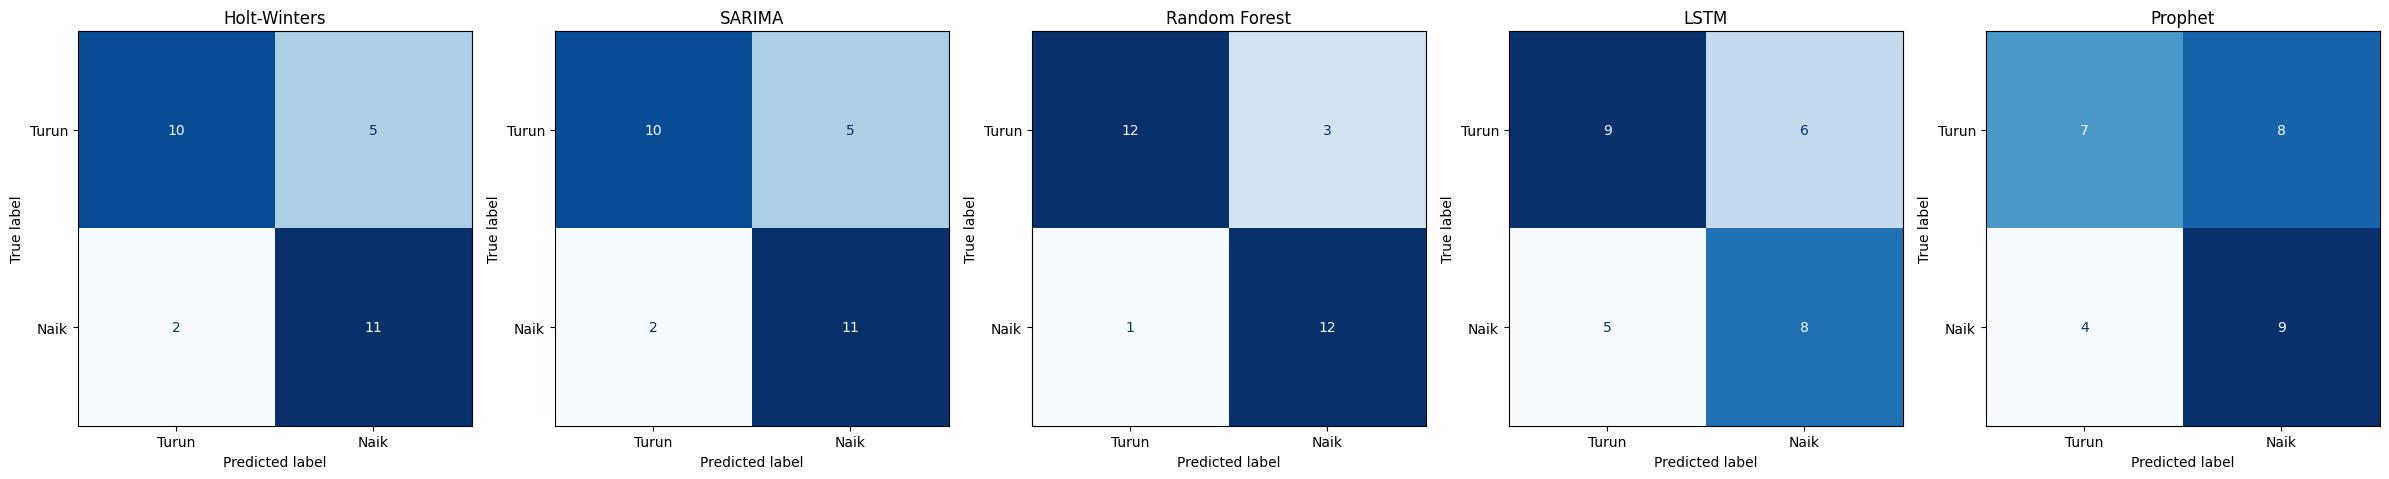

In [7]:
# ==========================================
# 7. CONFUSION MATRIX (KLASIFIKASI TREN NAIK/TURUN)
# ==========================================
print("\n=== CONFUSION MATRIX TREN PENJUALAN ===")

last_train_val = train.iloc[-1]
actual_shifted = np.append([last_train_val], test.values[:-1])
actual_trend = (test.values > actual_shifted).astype(int) # 1 = Naik, 0 = Turun

# 5 model untuk diplot
models_to_plot = ['Holt-Winters', 'SARIMA', 'Random Forest', 'LSTM', 'Prophet']
fig, axes = plt.subplots(1, 5, figsize=(24, 5))

for idx, model in enumerate(models_to_plot):
    pred_shifted = np.append([last_train_val], predictions[model].values[:-1])
    pred_trend = (predictions[model].values > pred_shifted).astype(int)

    cm = confusion_matrix(actual_trend, pred_trend, labels=[0, 1])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Turun', 'Naik'])
    disp.plot(ax=axes[idx], cmap='Blues', colorbar=False)
    axes[idx].set_title(f'{model}')

plt.tight_layout()
plt.show()